In [2]:
import os
import sqlite3
import pandas as pd

path_dict = {}
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            path_dict[filename] = os.path.join(dirname, filename)

orders = pd.read_csv(path_dict['olist_orders_dataset.csv'])
items = pd.read_csv(path_dict['olist_order_items_dataset.csv'])
customers = pd.read_csv(path_dict['olist_customers_dataset.csv'])

conn = sqlite3.connect(':memory:')

orders.to_sql('orders', conn, index=False, if_exists='replace')
items.to_sql('order_items', conn, index=False, if_exists='replace')
customers.to_sql('customers', conn, index=False, if_exists='replace')

99441

In [4]:
# Ən çox satış olan Top 5 şəhər və ortalama sifariş dəyəri
sql_query_1 = """
SELECT 
    c.customer_city,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    ROUND(AVG(oi.price), 2) AS avg_order_value
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_city
ORDER BY total_revenue DESC
LIMIT 5;
"""

pd.read_sql_query(sql_query_1, conn)

,customer_city,total_orders,total_revenue,avg_order_value
0,sao paulo,15045,1859556.83,106.87
1,rio de janeiro,6601,955573.97,125.87
2,belo horizonte,2697,346039.04,112.10
3,brasilia,2071,295814.72,126.36
4,curitiba,1489,205999.33,119.28


In [5]:
# Aylıq Satış Dinamikası (Month-over-Month Sales Growth)
sql_query_2 = """
WITH MonthlySales AS (
    SELECT 
        STRFTIME('%Y-%m', o.order_purchase_timestamp) AS sales_month,
        ROUND(SUM(oi.price), 2) AS revenue
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY sales_month
)
SELECT 
    sales_month,
    revenue,
    LAG(revenue, 1) OVER (ORDER BY sales_month) AS previous_month_revenue,
    ROUND(((revenue - LAG(revenue, 1) OVER (ORDER BY sales_month)) / LAG(revenue, 1) OVER (ORDER BY sales_month)) * 100, 2) AS growth_percentage
FROM MonthlySales
WHERE sales_month IS NOT NULL
ORDER BY sales_month;
"""

pd.read_sql_query(sql_query_2, conn)

,sales_month,revenue,previous_month_revenue,growth_percentage
0,2016-09,134.97,NaN,NaN
1,2016-10,40325.11,134.97,29777.09
2,2016-12,10.90,40325.11,-99.97
3,2017-01,111798.36,10.90,1025573.03
4,2017-02,234223.40,111798.36,109.51
5,2017-03,359198.85,234223.40,53.36
6,2017-04,340669.68,359198.85,-5.16
7,2017-05,489338.25,340669.68,43.64
8,2017-06,421923.37,489338.25,-13.78
9,2017-07,481604.52,421923.37,14.15


In [6]:
# VIP Müştəri Seqmentasiyası (Window Functions - NTILE)
sql_query_3 = """
WITH CustomerSpent AS (
    SELECT 
        c.customer_id,
        ROUND(SUM(oi.price), 2) AS total_spent
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY c.customer_id
)
SELECT 
    customer_id,
    total_spent,
    NTILE(4) OVER (ORDER BY total_spent DESC) AS spending_tier
FROM CustomerSpent
LIMIT 10;
"""

pd.read_sql_query(sql_query_3, conn)

,customer_id,total_spent,spending_tier
0,1617b1357756262bfa56ab541c47bc16,13440.0,1
1,ec5b2ba62e574342386871631fafd3fc,7160.0,1
2,c6e2731c5b391845f6800c97401a43a9,6735.0,1
3,f48d464a0baaea338cb25f816991ab1f,6729.0,1
4,3fd6777bbce08a352fddd04e4a7cc8f6,6499.0,1
5,05455dfa7cd02f13d132aa7a6a9729c6,5934.6,1
6,df55c14d1476a9a3467f131269c2477f,4799.0,1
7,24bbf5fd2f2e1b359ee7de94defc4a15,4690.0,1
8,e0a2412720e9ea4f26c1ac985f6a7358,4599.9,1
9,3d979689f636322c62418b6346b1c6d2,4590.0,1


/tmp/ipykernel_58/1030197504.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_city, x='total_revenue', y='customer_city', ax=axes[0], palette='Blues_r')


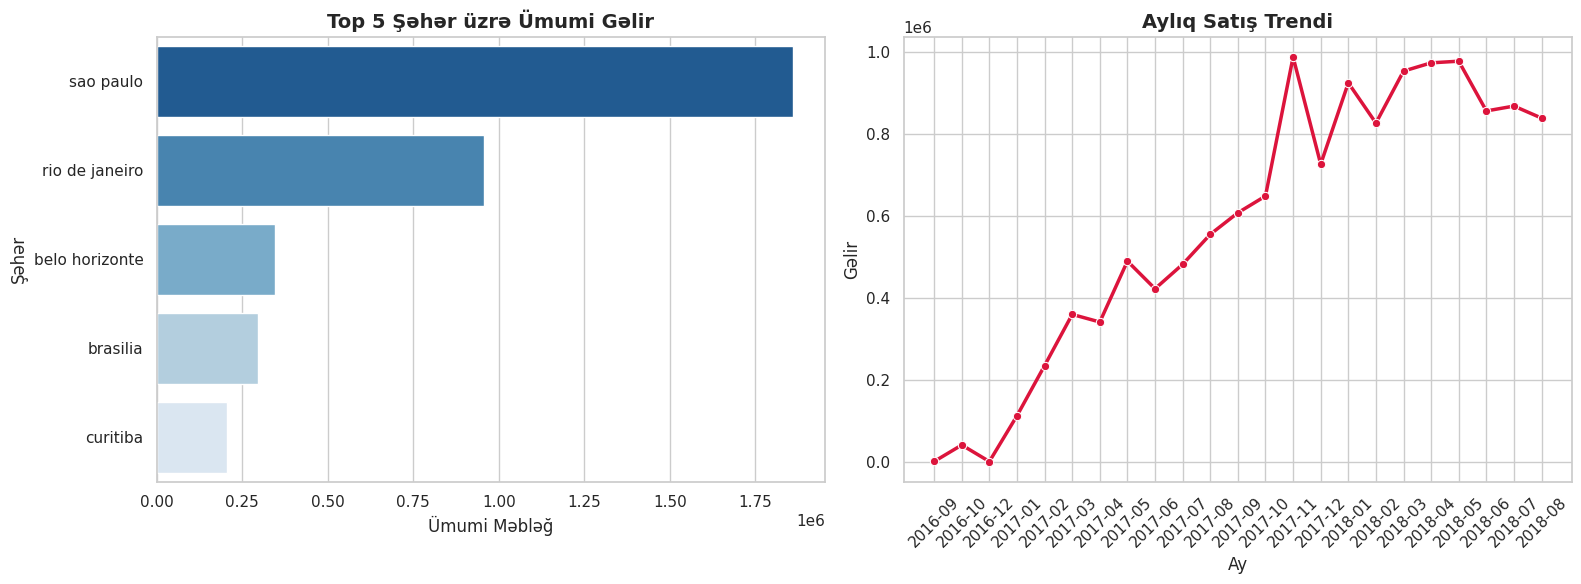

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Şəhərlər üzrə Ümumi Satış (Top 5 City Revenue)
df_city = pd.read_sql_query(sql_query_1, conn)
sns.barplot(data=df_city, x='total_revenue', y='customer_city', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 5 Şəhər üzrə Ümumi Gəlir', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Ümumi Məbləğ')
axes[0].set_ylabel('Şəhər')

# 2. Aylıq Satış Dinamikası (Monthly Sales Trend)
df_monthly = pd.read_sql_query(sql_query_2, conn)
sns.lineplot(data=df_monthly, x='sales_month', y='revenue', marker='o', ax=axes[1], color='crimson', linewidth=2.5)
axes[1].set_title('Aylıq Satış Trendi', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ay')
axes[1].set_ylabel('Gəlir')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()